# MA22018 Coursework 1

**Unit Testing**

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

def test_expsim():
    X = np.array([[1]])
    assert expsim(X) == 1, "Wrong expsim output for 1x1 matrix"
    X = np.array([[1,0]])
    assert expsim(X) == 1, "Wrong expsim output for 2x1 matrix"
    X = np.array([[1,0], [1,1]])
    assert np.allclose(expsim(X), np.exp(np.eye(2,2)-1)), "Wrong expsim output for 2x2 matrix"
    X = np.array([[1,0], [1,1], [0,2]])
    assert np.allclose(expsim(X), np.exp(-np.array([[0,1,5], [1,0,2], [5,2,0]]))), "Wrong expsim output for 3x2 matrix"
    X = np.array([[1,1,0], [0,1,1]])
    assert np.allclose(expsim(X), np.exp(-np.array([[0,2], [2,0]]))), "Wrong expsim output for 2x3 matrix"
    
def test_spectral_features():
    A = np.array([[0,1], [1,0]])
    U = spectral_features(A, 1)
    assert np.allclose(U/U[0], np.ones((2,1))), "Wrong spectral_features output for zero eigenvalue of graph *-*"
    U = spectral_features(A, 2)
    assert np.allclose(U.T @ U, np.eye(2,2)), "Wrong B-orthonormality of spectral_features of graph *-*"
    assert np.allclose(A @ U, U @ np.diag(np.diag(U.T @ A @ U))), "Large residual of spectral_features of graph *-*"
    A = np.array([[0,1,0], [1,0,1], [0,1,0]])
    U = spectral_features(A, 2)
    assert np.allclose(U.T @ np.diag([1,2,1]) @ U, np.eye(2,2)), "Wrong B-orthonormality of spectral_features of graph *-*-*"
    assert np.allclose(A @ U, np.diag([1,2,1]) @ U @ np.diag(np.diag(U.T @ A @ U))), "Large residual of spectral_features of graph *-*-*"

**Question 1**

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from sklearn.cluster import KMeans

def two_means():
    ''' Constructs dataset X and computes K_Means loss with 2 clusters and a single random 
    initialisation of centroids.
    Input: None
    Output: Clustering labels and K-Means loss'''
    X = np.array([[0,0],[0,1],[10,0],[10,1]]) # Construct dataset X as a numpy array
    kmeans = KMeans(n_clusters = 2,init = 'random',n_init = 1) # Note that scikitlearn KMeans uses LLoyds algorithm by default
    # which uses Euclidean Distance. 'random' means that KMeans chooses random rows from the data passed into it for the inital centroids.
    k_vec = kmeans.fit_predict(X) # Performs the clustering on X
    k_loss = kmeans.inertia_ # Gets the K-Means loss of the clustering
    labels = kmeans.labels_
    return labels,k_loss # Returns the clustering labels and K-Means loss


**Question 2**

In [30]:
# Lets make a function to make it easier to count how many times different clusterings appear
import math
import numpy as np

def match_clustering(cluster):
    ''' Matches the nparray of the cluster to a value representing the cluster as set out in Question 1
    Input: The np.array of the cluster
    Output: A value from 0 to 2 inclusive indicating which clustering each numpy array signifies. xi is the ith vector in the dataset X.
    0 indicates that x1 and x2 are clustered together.
    1 indicates that x1 and x3 are clustered together.
    2 indicates that x1 and x4 are clustered together.'''
    possible_clusters = [np.array([0,0,1,1]),np.array([1,1,0,0]),np.array([0,1,0,1]),np.array([1,0,1,0]),np.array([0,1,1,0]),np.array([1,0,0,1])]
    counter = 0
    matches = []
    while counter < len(possible_clusters):
        bools = (cluster == possible_clusters[counter])
        matches.append(0)
        for j in range(4):
            if bools[j] == False:
                matches[counter] += 1
        counter += 1 
    flag = matches.index(0)
    if flag == 0 or flag == 1:
        return 0
    elif flag == 2 or flag == 3:
        return 1
    elif flag == 4 or flag == 5:
        return 2
    else:
        return False            

# Test that match_clustering performs as wanted
cluster = np.array([0,0,1,1])
print(match_clustering(cluster))
cluster = np.array([1,1,0,0])
print(match_clustering(cluster))
cluster = np.array([0,1,0,1])
print(match_clustering(cluster))
cluster = np.array([1,0,1,0])
print(match_clustering(cluster))
cluster = np.array([0,1,1,0])
print(match_clustering(cluster))
cluster = np.array([1,0,0,1])
print(match_clustering(cluster))

0
0
1
1
2
2


In [31]:
import math
import numpy as np

print(f"The clusters possible are given below. Note that the 0s and 1s are interchangeable as since we only have 2 clusters the number is irrelevant")
print(f"Clustering 1: [0,0,1,1]. This is optimal with a loss of 1.")
print(f"Clustering 2: [0,1,0,1]. Has a loss of 100")
print(f"Clustering 3: [0,1,1,0]. Is not produced by two_means"  + '\n')


# Lets run the algorithm a small number of times and analyse results.
labels = []
losses = []
for i in range(5):
    clustering = two_means()
    labels.append(clustering[0])
    losses.append(clustering[1])
print(f"Example of the labels produced: {labels}") 
print(f"Corresponding losses: {losses}" + '\n')

# Now try for large n
counts = [0,0,0]

for i in range(1000):
    clustering = two_means()
    cluster_number = match_clustering(clustering[0])
    counts[cluster_number] = counts[cluster_number] + 1

print(f"Counts for 1000 runs shown in array ")
print(counts)
print("The actual probability of the optimal clustering is approximately 0.67")
print(f"Probability of choosing optimal clustering in this run = {counts[0] / sum(counts)}")

The clusters possible are given below. Note that the 0s and 1s are interchangeable as since we only have 2 clusters the number is irrelevant
Clustering 1: [0,0,1,1]. This is optimal with a loss of 1.
Clustering 2: [0,1,0,1]. Has a loss of 100
Clustering 3: [0,1,1,0]. Is not produced by two_means

Example of the labels produced: [array([0, 0, 1, 1], dtype=int32), array([0, 0, 1, 1], dtype=int32), array([1, 1, 0, 0], dtype=int32), array([0, 0, 1, 1], dtype=int32), array([0, 1, 0, 1], dtype=int32)]
Corresponding losses: [1.0, 1.0, 1.0, 1.0, 100.0]

Counts for 1000 runs shown in array 
[659, 341, 0]
The actual probability of the optimal clustering is approximately 0.67
Probability of choosing optimal clustering in this run = 0.659


**Question 3**

In [32]:
import math

def expsim(X):
    '''Takes numpy array and returns another aray of the exponential similarities between rows of X
    Input: matrix X of real values with dimensions m x n
    Output: Matrix S of real values with dimension m x m
    '''
    m,n = X.shape
    S = np.zeros((m,m))
    for i in range(m):
        for j in range(m):
            distances = [(X[i][k] - X[j][k]) ** 2 for k in range(n)]
            S[i][j] = np.exp(-1 * sum(distances))
    return S

In [33]:
# Check unit tests
print(test_expsim()) # Want none as if a mistake caught an error will be raised

None


**Question 4**

In [34]:
from scipy.linalg import eigh

def spectral_features(A,K):
    '''Takes a symmetric numpy array along with an integer K and returns a numpy array of generalised eigenvectors
    Input: A - Symmetric numpy array of real values with the dimensions m x m, K: Integer
    Output: Vector H tilda of K generalised eigenvectors
    '''
    # From the notes in the coursework we can find generalised engenvalues and eigenvectors from scipy.linalg.eigh
    m = A.shape[0] # Can use either 0 or 1 as A is a mxm matrix
    d_vec = np.zeros(m)
    for i in range(m):
        for j in range(m):
            d_vec[i] += A[i][j]
    D_mat = np.diag(d_vec)
    glaplace_mat = D_mat - A
    lambda_vec, u_mat = eigh(glaplace_mat,b=D_mat) # Note lambda_vec already sorted in ascending order from docs so can just take the first K 
    # eigenvectors from it
    h_tilda = u_mat[:, 0:K]
    return h_tilda
    

In [35]:
# Check unit tests
print(test_spectral_features()) # Want none as if a mistake caught an error will be raised

None


**Question 5**

In [36]:
def spectral_clustering(h_tilda,K):
    '''Computes the clustering labels and K-Means loss from a matrix of features and a number of clusters
    Input: numpy array h_tilda containing features for the K-Means, number of clusters K
    Output: Clustering labels k_vec, the K-Means loss k_loss'''
    kmeans = KMeans(n_clusters = K,init = 'random',n_init = 1) # Note that scikitlearn KMeans uses LLoyds algorithm by default
    # which uses Euclidean Distance. n_init = 1 signifies only one initilisation of the centroids listed in init.
    k_vec = kmeans.fit_predict(h_tilda) # Performs the clustering on h_tilda
    k_loss = kmeans.inertia_ # Gets the K-Means loss of the clustering
    labels = kmeans.labels_
    return labels, k_loss

# Construct the dataset X as defined in Q1
X = np.array([[0,0],[0,1],[10,0],[10,1]])
S_mat = expsim(X) # Computes exponential similarity matrix
features = spectral_features(S_mat,2) 
print(features)


counts = [0,0,0]

for i in range(50000):
    clustering = spectral_clustering(features,2)
    cluster_number = match_clustering(clustering[0])
    counts[cluster_number] = counts[cluster_number] + 1

print(counts)
print(sum(counts))
print(f"Probability K-Means Algorithm converges to optimal clustering = {counts[0] / sum(counts)}")

[[-6.04590183e-01  0.00000000e+00]
 [-6.04590183e-01 -8.36286729e-44]
 [-6.11374587e-44  6.04590183e-01]
 [-2.24912141e-44  6.04590183e-01]]
[50000, 0, 0]
50000
Probability K-Means Algorithm converges to optimal clustering = 1.0


**Question 9**

In [37]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

Data = np.load('BathPages.npz')
titles = Data['titles']
docs = Data['docs']

tv_obj = TfidfVectorizer(stop_words='english', norm='l2') # l2 means sum of squares of vector elements equals 1 from the documentation
X_array = tv_obj.fit_transform(docs).toarray() # Computes the TF.IDF ttd matrix, automatically includes 2-norm = 1
S_mat = expsim(X_array) # Computes the exponential similarity matrix of the documents

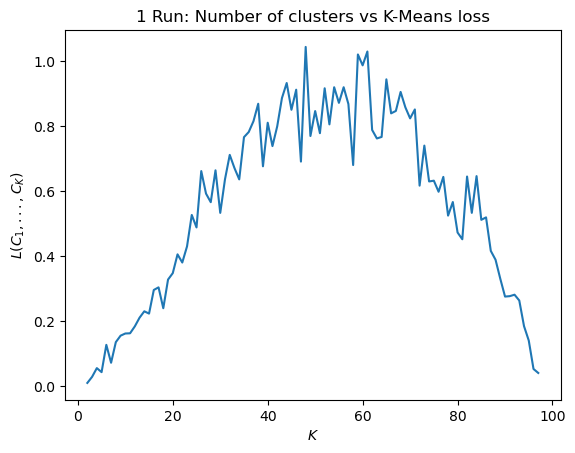

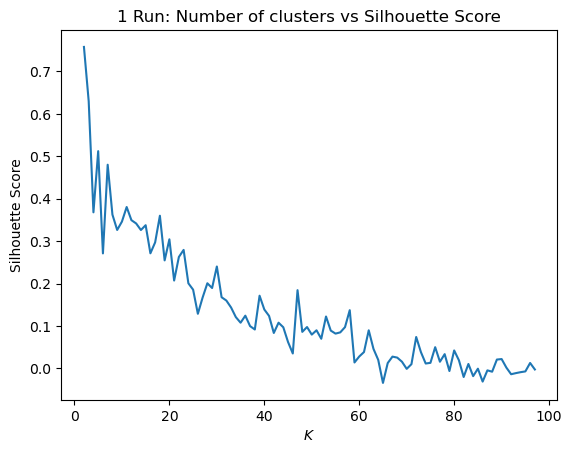

[1, 2, 4, 6, 7, 8, 9, 10, 11, 12, 14, 15, 17, 18, 19, 21, 22, 24, 27, 29, 30, 33, 34, 35, 36, 38, 40, 41, 42, 44, 46, 48, 50, 52, 54, 57, 59, 62, 63, 65, 66, 69, 71, 73, 75, 77, 80, 82, 84, 89, 90]
Maximum silhouette score 0.7576418747031566 is at K = 2
At the maximum silhouette score K = 2 the loss is 0.010097146949237553


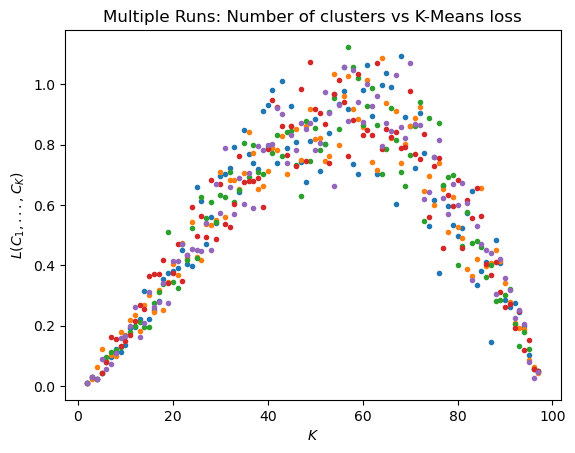

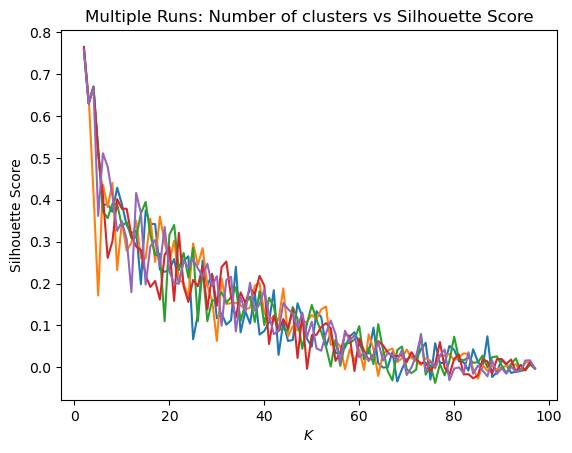

In [38]:
# When we have set the number of eigenvectors equal to the number of clusters:

from sklearn.metrics import silhouette_score, rand_score
from matplotlib import pyplot as plt

labels = []
losses = []
sil_scores = []

# Will use the approach from problem sheet 4 to plot the KMeans loss but also adapt it for a single run as well and also to plot the silhouette score

# Plot for a single run:
for K in range(2,98):
    features = spectral_features(S_mat, K)
    kmeans = KMeans(n_clusters = K,init = 'random',n_init = 1)
    k_vec = kmeans.fit_predict(features) # Computes and gets the clustering labels for h_tilda
    k_loss = kmeans.inertia_ # Gets the K-Means loss of the clustering
    cluster_labels = kmeans.labels_
    k_loss = kmeans.inertia_ # Gets the K-Means loss of the clustering
    silhou_score = silhouette_score(features,cluster_labels)
    labels.append(cluster_labels)
    losses.append(k_loss)
    sil_scores.append(silhou_score)  

# Plot the number of clusters vs K-Means Loss
losses = np.array(losses)
plt.plot(np.arange(2,losses.shape[0]+2), losses,)
plt.xlabel("$K$")
plt.ylabel("$L(C_1,...,C_K)$")
plt.title("1 Run: Number of clusters vs K-Means loss")
plt.show()

# Plot the number of clusters vs Silhouette score
plt.plot(np.arange(2,98,1),sil_scores)
plt.xlabel("$K$")
plt.ylabel("Silhouette Score")
plt.title("1 Run: Number of clusters vs Silhouette Score")
plt.show()

increases = []
for i in range(len(losses) - 1):
    if losses[i] <= losses[i+1]:
        increases.append(i+1)
print(increases)
max_sil = sil_scores.index(max(sil_scores)) + 2 # +2 needed as K starts from 2 and not 0
print(f"Maximum silhouette score {max(sil_scores)} is at K = {max_sil}")
features = spectral_features(S_mat, max_sil)
kmeans = KMeans(n_clusters = max_sil,init = 'random',n_init = 1)
kvec = kmeans.fit_predict(features)
k_loss = kmeans.inertia_
print(f"At the maximum silhouette score K = {max_sil} the loss is {k_loss}")

# Plots for multiple runs:

labels = []
losses = []
sil_scores = []
nruns = 5

for K in range(2,98):
    features = spectral_features(S_mat, K)
    loss_K = []
    silhou_score = []
    for i in range(nruns):
        kmeans = KMeans(n_clusters = K,init = 'random',n_init = 1)
        k_vec = kmeans.fit_predict(features) # Computes and gets the clustering labels for h_tilda
        loss_K.append(kmeans.inertia_) # Gets the K-Means loss of the clustering
        cluster_labels = kmeans.labels_
        silhou_score.append(silhouette_score(features,cluster_labels))
    # cluster_labels = kmeans.labels_
    k_loss = kmeans.inertia_ # Gets the K-Means loss of the clustering
    # silhou_score = silhouette_score(features,cluster_labels)
    labels.append(cluster_labels)
    losses.append(loss_K)
    sil_scores.append(silhou_score)  

# Plot the number of clusters vs K-Means Loss
losses = np.array(losses)
plt.plot(np.arange(2,losses.shape[0]+2), losses, '.')
plt.xlabel("$K$")
plt.ylabel("$L(C_1,...,C_K)$")
plt.title("Multiple Runs: Number of clusters vs K-Means loss")
plt.show()

# Plot the number of clusters vs Silhouette score
plt.plot(np.arange(2,98,1),sil_scores)
plt.xlabel("$K$")
plt.ylabel("Silhouette Score")
plt.title("Multiple Runs: Number of clusters vs Silhouette Score")
plt.show()


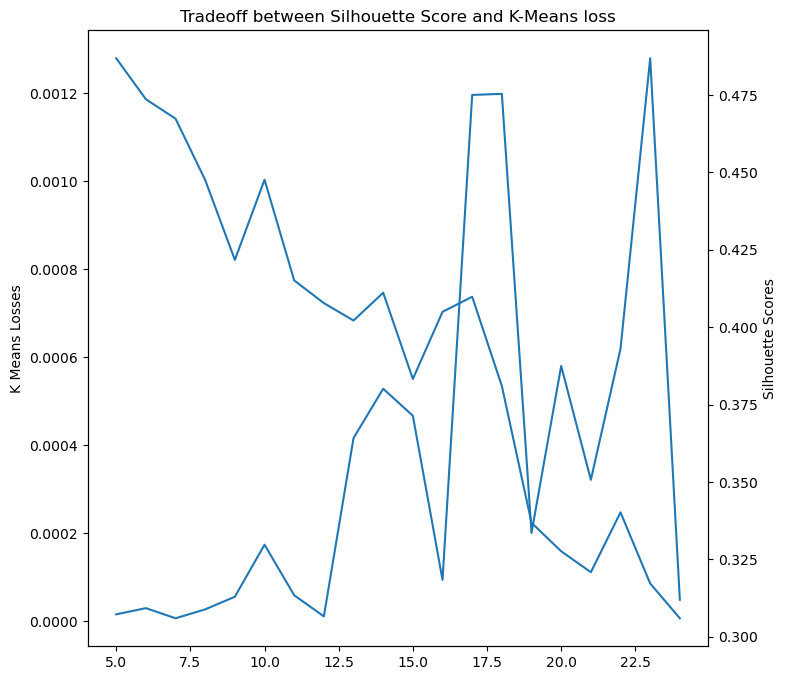

In [39]:
# Find optimal number of eigenvectors for the features
from sklearn.metrics import silhouette_score, rand_score
from matplotlib import pyplot as plt

total_loss = []
total_sil = []
for i in range(5,25):
    labels = []
    losses = []
    sil_scores = []
    features = spectral_features(S_mat,i)
    for K in range(2,98):
        kmeans = KMeans(n_clusters = K,init = 'random',n_init = 1)
        k_vec = kmeans.fit_predict(features) # Computes and gets the clustering labels for h_tilda
        k_loss = kmeans.inertia_ # Gets the K-Means loss of the clustering
        cluster_labels = kmeans.labels_
        k_loss = kmeans.inertia_ # Gets the K-Means loss of the clustering
        silhou_score = silhouette_score(features,cluster_labels)
        labels.append(cluster_labels)
        losses.append(k_loss)
        sil_scores.append(silhou_score)
    total_loss.append(min(losses))
    total_sil.append(max(sil_scores))

fig, ax1 = plt.subplots(figsize=(8, 8))
ax2 = ax1.twinx()

ax1.plot(range(5,25), total_loss)
ax1.set_ylabel("K Means Losses")
ax2.plot(range(5,25), total_sil);
ax2.set_ylabel("Silhouette Scores")
plt.title("Tradeoff between Silhouette Score and K-Means loss")
plt.show()

(98, 10)


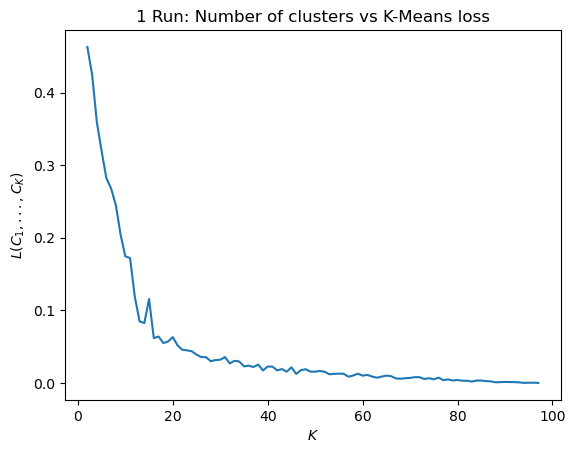

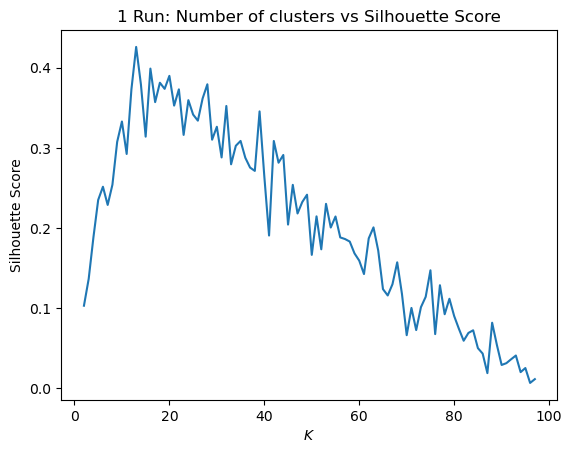

Maximum silhouette score 0.42601297406978444 is at K = 13
At the maximum silhouette score K = 13 the loss is 0.08398320476052154


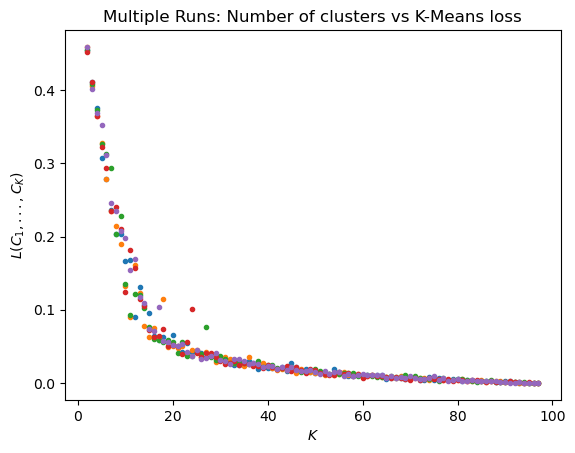

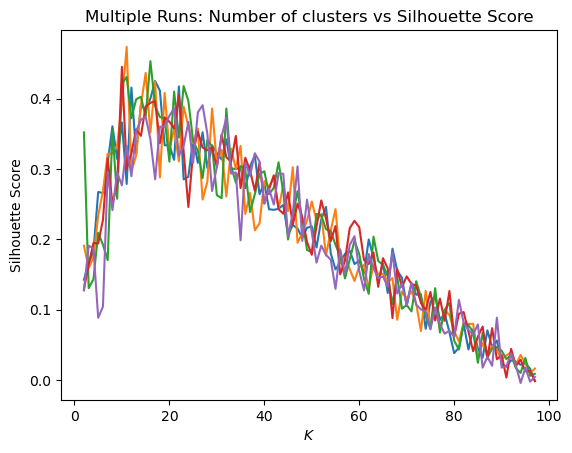

In [43]:
# From running the above program many times the optimal tradeoff is at K = 10 or K = 11. 10 appears more often so we choose 10.

# Find optimal number of clusters

from sklearn.metrics import silhouette_score, rand_score
from matplotlib import pyplot as plt

labels = []
losses = []
sil_scores = []
features = spectral_features(S_mat, 10)
print(features.shape) # features has 98 rows so you can have a maximum of 98 clusters.

# Will use the approach from problem sheet 4 to plot the KMeans loss but also adapt it for a single run as well and also to plot the silhouette score

#Plot for a single run:
for K in range(2,98):
    kmeans = KMeans(n_clusters = K,init = 'random',n_init = 1)
    k_vec = kmeans.fit_predict(features) # Computes and gets the clustering labels for h_tilda
    k_loss = kmeans.inertia_ # Gets the K-Means loss of the clustering
    cluster_labels = kmeans.labels_
    k_loss = kmeans.inertia_ # Gets the K-Means loss of the clustering
    silhou_score = silhouette_score(features,cluster_labels)
    labels.append(cluster_labels)
    losses.append(k_loss)
    sil_scores.append(silhou_score)

# Plot the number of clusters vs K-Means Loss
losses = np.array(losses)
plt.plot(np.arange(2,losses.shape[0]+2), losses,)
plt.xlabel("$K$")
plt.ylabel("$L(C_1,...,C_K)$")
plt.title("1 Run: Number of clusters vs K-Means loss")
plt.show()

# Plot the number of clusters vs Silhouette score
plt.plot(np.arange(2,98,1),sil_scores)
plt.xlabel("$K$")
plt.ylabel("Silhouette Score")
plt.title("1 Run: Number of clusters vs Silhouette Score")
plt.show()

max_sil = sil_scores.index(max(sil_scores)) + 2 # +2 needed as K starts from 2 and not 0
print(f"Maximum silhouette score {max(sil_scores)} is at K = {max_sil}")
kmeans = KMeans(n_clusters = max_sil,init = 'random',n_init = 1)
kvec = kmeans.fit_predict(features)
k_loss = kmeans.inertia_
print(f"At the maximum silhouette score K = {max_sil} the loss is {k_loss}")

# Plots for multiple runs:

labels = []
losses = []
sil_scores = []
nruns = 5

for K in range(2,98):
    loss_K = []
    silhou_score = []
    for i in range(nruns):
        kmeans = KMeans(n_clusters = K,init = 'random',n_init = 1)
        k_vec = kmeans.fit_predict(features) # Computes and gets the clustering labels for h_tilda
        loss_K.append(kmeans.inertia_) # Gets the K-Means loss of the clustering
        cluster_labels = kmeans.labels_
        silhou_score.append(silhouette_score(features,cluster_labels))
    # cluster_labels = kmeans.labels_
    k_loss = kmeans.inertia_ # Gets the K-Means loss of the clustering
    # silhou_score = silhouette_score(features,cluster_labels)
    labels.append(cluster_labels)
    losses.append(loss_K)
    sil_scores.append(silhou_score)  

# Plot the number of clusters vs K-Means Loss
losses = np.array(losses)
plt.plot(np.arange(2,losses.shape[0]+2), losses, '.')
plt.xlabel("$K$")
plt.ylabel("$L(C_1,...,C_K)$")
plt.title("Multiple Runs: Number of clusters vs K-Means loss")
plt.show()

# Plot the number of clusters vs Silhouette score
plt.plot(np.arange(2,98,1),sil_scores)
plt.xlabel("$K$")
plt.ylabel("Silhouette Score")
plt.title("Multiple Runs: Number of clusters vs Silhouette Score")
plt.show()

In [44]:
# Choosing the numnber of eigenvectors to be 10 we then find that the optimal number of clusters is 13 for a high silhouette score and a low 
# K-Means loss

K_star = 13

klosses = []
silscores = []
features = spectral_features(S_mat,10)
nruns = 500
k_vecs = []
for i in range(nruns):
        kmeans = KMeans(n_clusters = K_star,init = 'random',n_init = 1)
        k_vec = kmeans.fit_predict(features) # Computes and gets the clustering labels for h_tilda
        k_vecs.append(k_vec)
        klosses.append(kmeans.inertia_) # Gets the K-Means loss of the clustering
        cluster_labels = kmeans.labels_
        silscores.append(silhouette_score(features,cluster_labels))
k_vecs = cluster_labels

print("For spectral clustering")
print(f"The average k-means loss for K = {K_star} is {sum(klosses) / len(klosses)}")
print(f"The average silhouette score for K = {K_star} is {sum(silscores) / len(silscores)}" + '\n')

klosses = []
silscores = []
nruns = 500
for i in range(nruns):
        kmeans = KMeans(n_clusters = 10,init = 'random',n_init = 1)
        k_vec = kmeans.fit_predict(X_array) # Computes and gets the clustering labels for h_tilda
        klosses.append(kmeans.inertia_) # Gets the K-Means loss of the clustering
        cluster_labels = kmeans.labels_
        silscores.append(silhouette_score(X_array,cluster_labels))

print("For direct K-Means clustering")
print(f"The average k-means loss for K = 10 is {sum(klosses) / len(klosses)}")
print(f"The average silhouette score for K = 10 is {sum(silscores) / len(silscores)}" + '\n')


print("Spectral Clusters:")
for i in range(np.max(k_vecs)+1):
    print(f"Cluster {i+1}:")
    print(titles[k_vecs==i])

For spectral clustering
The average k-means loss for K = 13 is 0.10960886578032077
The average silhouette score for K = 13 is 0.3684583235535455

For direct K-Means clustering
The average k-means loss for K = 10 is 65.36303165987742
The average silhouette score for K = 10 is 0.05107591838793337

Spectral Clusters:
Cluster 1:
['Choose your postgraduate student accommodation options'
 'Pulteney Court student accommodation' 'Polden student accommodation'
 'Thornbank Gardens student accommodation'
 'Choose your undergraduate student accommodation options'
 'Woodland Court student accommodation'
 'Canal Wharf student accommodation' 'The Quads student accommodation'
 'Clevelands Building student accommodation' 'Postgraduate Living'
 'Carpenter House student accommodation'
 'Eastwood Terrace student accommodation'
 'Marlborough Court and Solsbury Court student accommodation'
 'Eastwood Green student accommodation']
Cluster 2:
['4 West' '6 West South' '1 West' '10 West Graduate Commons' '10 We